# Figure 1

In [1]:
%matplotlib inline

In [2]:
import sys
sys.path.append('..')
from utils.plotting import plot_hic, plot_n_hic, genomic_labels, format_ticks, set_genomic_ticks
from utils.processing import read_hic_file
from utils.scale_space import construct_scale_space_helper
from notebooks.func_pileup import generate_bed_2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

Use mm10 remapped for Figure 1

In [3]:
hic_file = "/nfs/turbo/umms-minjilab/downloaded_data/DP-thymocytes_WT_hic_Guo-2022_GSE199059_mm10-remapped.hic"

result_type = "saliency-90-p-0.1" # MIA-Jet
f_pred_miajet_summary = f"/nfs/turbo/umms-minjilab/sionkim/miajet_output/DP-thymocytes_WT_hic_Guo-2022_GSE199059_mm10-remapped_chr_combined_50Kb/DP-thymocytes_WT_hic_Guo-2022_GSE199059_mm10-remapped_chr_combined_{result_type}_50Kb_summary_table.csv"
f_pred_miajet_expanded = f"/nfs/turbo/umms-minjilab/sionkim/miajet_output/DP-thymocytes_WT_hic_Guo-2022_GSE199059_mm10-remapped_chr_combined_50Kb/DP-thymocytes_WT_hic_Guo-2022_GSE199059_mm10-remapped_chr_combined_{result_type}_50Kb_expanded_table.csv"

In [4]:
resolution = int(50e3) # 25Kb resolution
data_type = "oe"
normalization = "KR"

In [5]:
# Read in results
miajet_positions = pd.read_csv(f_pred_miajet_expanded, comment="#")
miajet_table = pd.read_csv(f_pred_miajet_summary, comment="#")

In [6]:
miajet_table = miajet_table.loc[miajet_table["chrom"] == "chr3"].reset_index(drop=True)
miajet_positions = miajet_positions.loc[miajet_positions["chrom"] == "chr3"].reset_index(drop=True)

In [7]:
miajet_table 

,unique_id,chrom,start,end,length,input_mean,angle_mean,width_mean,jet_saliency,ks,p-val_raw,p-val_corr,stripiness
0,chr3_128_6,chr3,3.697378e+07,3.720636e+07,400000,0.150,92.600,3.035,0.063,0.875,0.001,0.008,0.024
1,chr3_60_9,chr3,8.478031e+07,8.493416e+07,300000,0.228,97.728,3.636,0.056,1.000,0.001,0.007,0.067
2,chr3_29_17,chr3,6.564155e+07,6.584654e+07,350000,0.256,90.899,0.993,0.062,0.857,0.004,0.022,0.005
3,chr3_3588_3,chr3,6.050789e+07,6.073745e+07,850000,0.267,113.157,3.385,0.048,1.000,0.000,0.000,0.070
4,chr3_164_3,chr3,1.043136e+08,1.044907e+08,300000,0.253,92.445,3.773,0.045,1.000,0.001,0.007,0.048
5,chr3_39_9,chr3,5.610249e+06,6.650270e+06,1600000,0.240,92.657,7.235,0.410,0.969,0.000,0.000,0.077
6,chr3_5320_1,chr3,1.310243e+08,1.311940e+08,300000,0.272,106.237,3.986,0.112,1.000,0.001,0.007,0.086
7,chr3_2171_6,chr3,1.197906e+08,1.204205e+08,900000,0.179,87.477,5.728,0.238,0.722,0.000,0.001,0.049


In [8]:
uid = "chr3_39_9"

In [9]:
miajet_table = miajet_table.loc[miajet_table["unique_id"] == uid].reset_index(drop=True)
miajet_positions = miajet_positions.loc[miajet_positions["unique_id"] == uid].reset_index(drop=True)
miajet_positions.sort_values(by=["y (pixels)"], inplace=True) # Why are positions not sorted?

In [10]:
A = read_hic_file(hic_file, chrom="chr3", resolution=resolution, data_type=data_type, normalization=normalization, positions="all", verbose=False)

In [11]:
miajet_bed = generate_bed_2(miajet_table, miajet_positions, eps=800e3, fraction=1.5)

In [12]:
genomic_labels(miajet_bed["start"].values[0], N=2)

'2.95Mb'

In [13]:
genomic_labels(miajet_bed["end"].values[0], N=2)

'8.10Mb'

In [14]:
# Subtract offset from the positions
miajet_positions["x (bp)"] -= miajet_bed["start"].values[0]
miajet_positions["y (bp)"] -= miajet_bed["start"].values[0]

In [15]:
x1 = miajet_bed["start"].values[0] / resolution
x2 = miajet_bed["end"].values[0] / resolution

mp = (x1 + x2) / 2

In [16]:
x1 = np.ceil(x1).astype(int) - 1
x2 = np.ceil(x2).astype(int) 

A = A[x1:x2, x1:x2]

In [17]:
s_range = [0.5, 4, 15]

In [18]:
D_list = []
for s in s_range:
    d_each, _, _, _, _, _, _ = construct_scale_space_helper(s=s, im=A, gamma=0.75, ridge_strength_method=1, scale_space_filter="gaussian", 
                             filter_mode="mirror", zc_method=2, zc_ks=5, eps_r=0.0005, eps_c1=0.1, eps_c2=1e-5)
    D_list.append(d_each)

In [19]:
# common_vmax = np.percentile(np.array(D_list), 99)

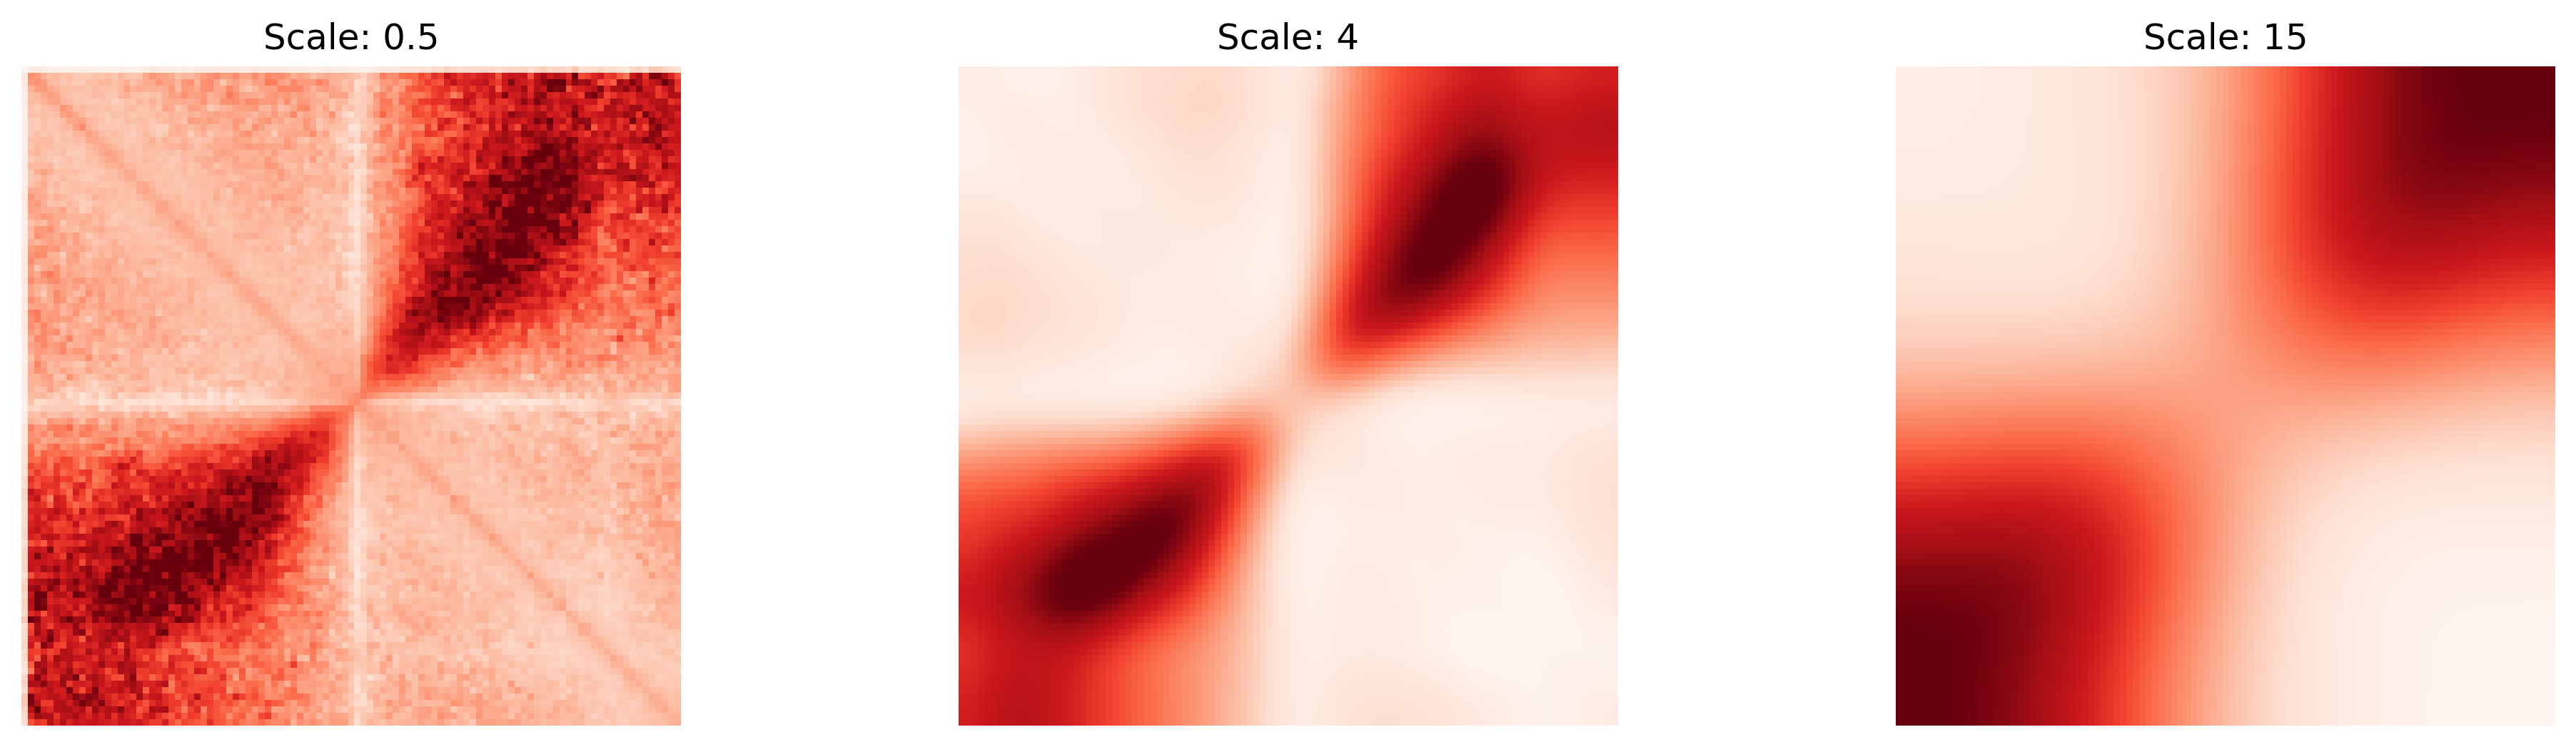

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4), dpi=300)

for i, D in enumerate(D_list):
    ax[i].imshow(D, cmap="Reds", interpolation="none", vmax=np.percentile(D, 98))
    ax[i].set_title(f"Scale: {s_range[i]}")
    ax[i].set_axis_off()


plt.show()

In [18]:
I, D, W1, W2, V, R, C = construct_scale_space_helper(s=0.75, im=A, gamma=0.75, ridge_strength_method=1, scale_space_filter="gaussian", 
                             filter_mode="nearest", zc_method=2, zc_ks=5, eps_r=0.0005, eps_c1=0.1, eps_c2=1e-5)

In [19]:
from scipy.ndimage import gaussian_filter

A = gaussian_filter(A, sigma=0.75)

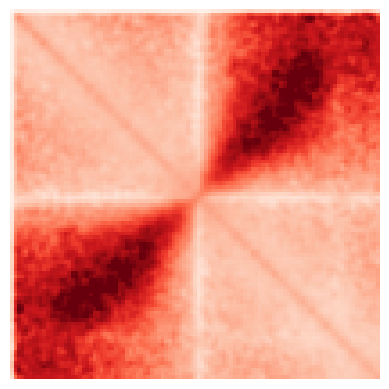

In [23]:
plt.imshow(A, cmap="Reds", interpolation="none", vmax=np.percentile(A, 98))

ax = plt.gca()

# remove axis
ax.set_axis_off()

plt.show()

In [20]:
x_vals = miajet_positions["x (bp)"].values / resolution
y_vals = miajet_positions["y (bp)"].values / resolution

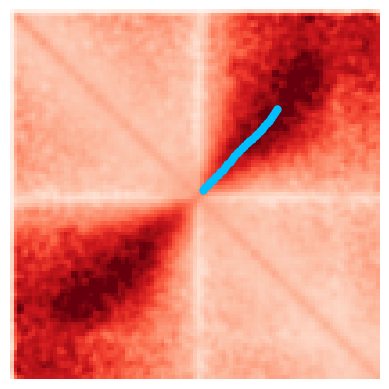

In [25]:
plt.imshow(A, cmap="Reds", interpolation="none", vmax=np.percentile(A, 98))

ax = plt.gca()

# remove axis
ax.set_axis_off()

# plt.scatter(x=x_vals, y=y_vals, s=3.5, c="deepskyblue", alpha=1)
ax.plot(x_vals, y_vals, 
        color='deepskyblue',
        linewidth=3,
        linestyle='-')

ax.plot(x_vals, y_vals, 
        linestyle='None',
        marker='o',
        markersize=5,
        markerfacecolor='deepskyblue', markeredgecolor='deepskyblue')


plt.show()

In [21]:
import matplotlib.tri as mtri

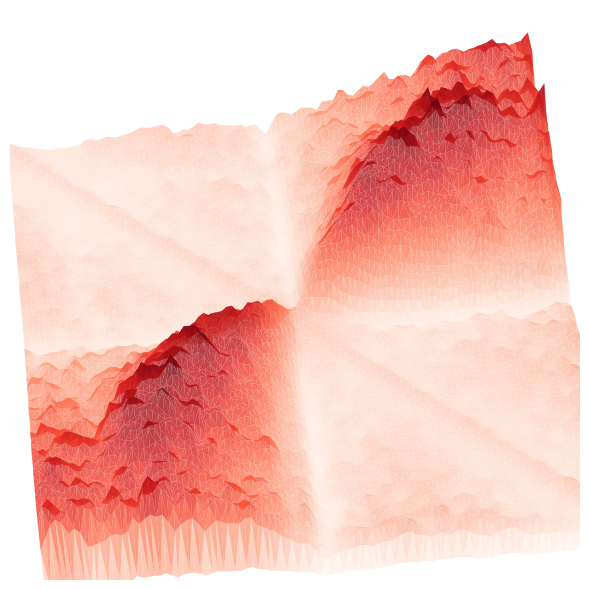

In [22]:
x = np.arange(A.shape[1])
y = np.arange(A.shape[0])
X, Y = np.meshgrid(x, y)


triang = mtri.Triangulation(X.ravel(), Y.ravel())

fig = plt.figure(figsize=(10, 6))
ax  = plt.axes(projection='3d', computed_zorder=False)

ax.plot_trisurf(triang, A.ravel(),
                cmap='Reds',
                alpha=0.8,
                edgecolor='none')

# styling
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Height')
ax.set_axis_off()
ax.view_init(elev=50, azim=173)
ax.set_box_aspect((3, 3, 1), zoom=1.6)
plt.tight_layout()
plt.show()

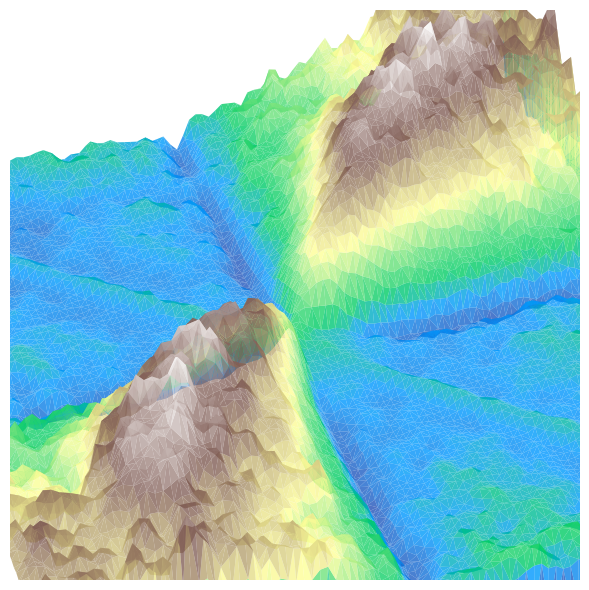

In [29]:
x = np.arange(A.shape[1])
y = np.arange(A.shape[0])
X, Y = np.meshgrid(x, y)


triang = mtri.Triangulation(X.ravel(), Y.ravel())

fig = plt.figure(figsize=(10, 6))
ax  = plt.axes(projection='3d', computed_zorder=False)

ax.plot_trisurf(triang, A.ravel(),
                cmap='terrain',
                alpha=0.8,
                edgecolor='none')

# styling
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Height')
ax.set_axis_off()
ax.view_init(elev=40, azim=160)
ax.set_box_aspect((3, 3, 1), zoom=2.2)
plt.tight_layout()
plt.show()

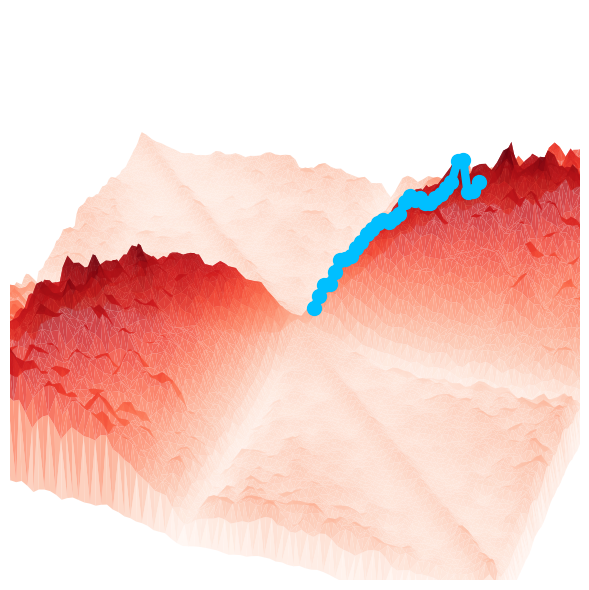

In [28]:
x = np.arange(A.shape[1])
y = np.arange(A.shape[0])
X, Y = np.meshgrid(x, y)

points  = np.column_stack((X.ravel(), Y.ravel()))
values  = A.ravel()
z_vals  = griddata(points, values, (x_vals, y_vals), method='nearest')

triang = mtri.Triangulation(X.ravel(), Y.ravel())

fig = plt.figure(figsize=(10, 6))
ax  = plt.axes(projection='3d', computed_zorder=False, zorder=1)

ax.plot_trisurf(triang, A.ravel(), cmap='Reds', alpha=0.8, edgecolor='none')

ax.plot(x_vals, y_vals, z_vals,
        color='deepskyblue',
        linewidth=6,
        linestyle='-')

ax.plot(x_vals, y_vals, z_vals,
        linestyle='None',
        marker='o',
        markersize=10,
        markerfacecolor='deepskyblue', markeredgecolor='deepskyblue')

# styling
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Height')
ax.set_axis_off()
ax.view_init(elev=35, azim=200)
ax.set_box_aspect((3, 3, 1), zoom=1.7)
plt.tight_layout()

plt.show()

In [29]:
miajet_positions

,unique_id,chrom,x (bp),y (bp),x (pixels),y (pixels),width,angle_imagej,ridge_strength
16,chr3_39_9,chr3,3698083.001,1362383.635,155.480,51.114,10.648,101.306,0.008
15,chr3_39_9,chr3,3671141.656,1402817.991,155.671,52.067,10.695,101.507,0.009
14,chr3_39_9,chr3,3644729.367,1443530.101,155.874,53.016,10.677,101.277,0.009
13,chr3_39_9,chr3,3617282.955,1483769.489,156.054,53.973,10.659,100.452,0.010
12,chr3_39_9,chr3,3588177.960,1523312.794,156.202,54.944,10.641,99.190,0.010
24,chr3_39_9,chr3,3552200.522,1563421.857,156.261,56.020,10.621,92.943,0.011
23,chr3_39_9,chr3,3519743.980,1599501.614,156.312,56.989,10.603,91.010,0.011
22,chr3_39_9,chr3,3490467.330,1636330.165,156.419,57.924,10.585,94.658,0.012
21,chr3_39_9,chr3,3455258.719,1671954.554,156.424,58.926,10.486,93.424,0.013
20,chr3_39_9,chr3,3420196.512,1707592.346,156.433,59.926,10.146,92.390,0.014


In [30]:
theta_vals = np.radians(miajet_positions["angle_imagej"].values - 45) 

In [31]:
from matplotlib.tri import LinearTriInterpolator

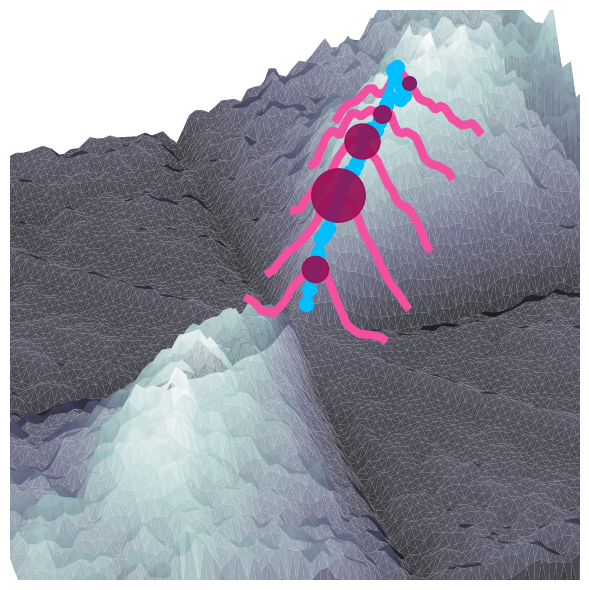

In [214]:
max_dist  = 10.0
n_samples = 100
K = 7

# Surface
x = np.arange(A.shape[1])
y = np.arange(A.shape[0])
X, Y = np.meshgrid(x, y)
triang = mtri.Triangulation(X.ravel(), Y.ravel())
interp_z = LinearTriInterpolator(triang, A.ravel())

fig = plt.figure(figsize=(10, 6))
ax  = plt.axes(projection='3d', computed_zorder=False)

ax.plot_trisurf(triang, A.ravel(), cmap='bone', alpha=0.8, edgecolor='none')

# Blue scatter points
points  = np.column_stack((X.ravel(), Y.ravel()))
values  = A.ravel()
z_vals  = griddata(points, values, (x_vals, y_vals), method='nearest')

saliency_values = D.ravel()
z_saliency_vals = griddata(points, saliency_values, (x_vals, y_vals), method='nearest')
z_saliency_vals = np.abs(z_saliency_vals)

ax.plot(x_vals, y_vals, z_vals,
        color='deepskyblue',
        linewidth=6,
        linestyle='-', zorder=10)

ax.plot(x_vals, y_vals, z_vals,
        linestyle='None',
        marker='o',
        markersize=10,
        markerfacecolor='deepskyblue', 
        markeredgecolor='deepskyblue', zorder=10)


# Wires
x_min, x_max = X.min()+0.5, X.max()-0.5
y_min, y_max = Y.min()+0.5, Y.max()-0.5

for idx, (x0, y0, theta) in enumerate(zip(x_vals.ravel(), y_vals.ravel(), theta_vals.ravel())):


    
    if idx % K:
        continue

    
    dx, dy = np.cos(theta), np.sin(theta)
    with np.errstate(divide='ignore', invalid='ignore'):
        t_border = np.min(np.where([dx>0, dx<0, dy>0, dy<0],
                                [(x_max-x0)/dx, (x_min-x0)/dx,
                                 (y_max-y0)/dy, (y_min-y0)/dy],
                                np.inf))
        
    t_half = np.clip(t_border, a_min=None, a_max=max_dist)

    t  = np.linspace(-t_half, t_half, n_samples)
    xs = x0 + t * dx
    ys = y0 + t * dy
    zs = interp_z(xs, ys)

    ax.plot(xs, ys, zs, color="#F350A1", linewidth=6, zorder=5)
    ax.scatter(x0, y0, z_vals[idx], zorder=15, color="#970E53", s=(z_saliency_vals[idx] * 12.5) ** 9, alpha=0.9)
    # ax.scatter(x0, y0, z_vals[idx], zorder=15, color="#970E53", s=(z_saliency_vals[idx] * 1000), alpha=0.9)

ax.set_axis_off()
ax.view_init(elev=40, azim=160)
ax.set_box_aspect((3, 3, 1), zoom=2.2)
plt.tight_layout()
plt.show()


In [33]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

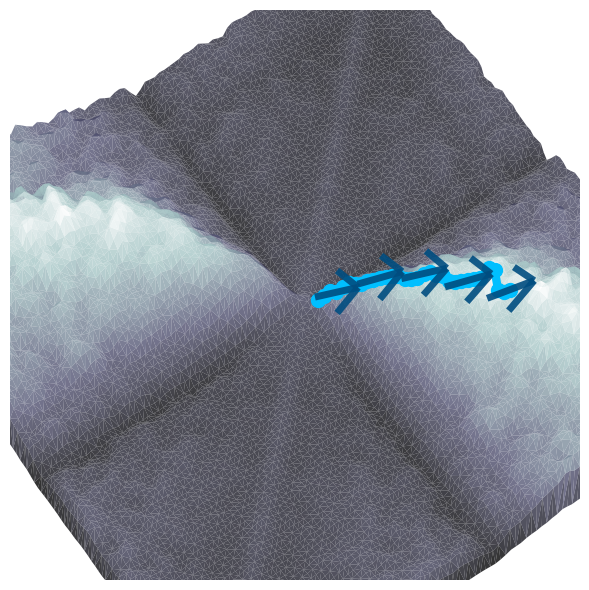

In [34]:
max_dist  = 10.0
n_samples = 100
K = 7

# Surface
x = np.arange(A.shape[1])
y = np.arange(A.shape[0])
X, Y = np.meshgrid(x, y)
triang = mtri.Triangulation(X.ravel(), Y.ravel())
interp_z = LinearTriInterpolator(triang, A.ravel())

fig = plt.figure(figsize=(10, 6))
ax  = plt.axes(projection='3d', computed_zorder=False)

ax.plot_trisurf(triang, A.ravel(), cmap='bone', alpha=0.8, edgecolor='none')

# Blue scatter points
points  = np.column_stack((X.ravel(), Y.ravel()))
values  = A.ravel()
z_vals  = griddata(points, values, (x_vals, y_vals), method='nearest')

saliency_values = D.ravel()
z_saliency_vals = griddata(points, saliency_values, (x_vals, y_vals), method='nearest')
z_saliency_vals = np.abs(z_saliency_vals)

ax.plot(x_vals, y_vals, z_vals,
        color='deepskyblue',
        linewidth=6,
        linestyle='-', zorder=10)

ax.plot(x_vals, y_vals, z_vals,
        linestyle='None',
        marker='o',
        markersize=10,
        markerfacecolor='deepskyblue', 
        markeredgecolor='deepskyblue', zorder=10)


# Wires
x_min, x_max = X.min()+0.5, X.max()-0.5
y_min, y_max = Y.min()+0.5, Y.max()-0.5

for idx, (x0, y0, theta) in enumerate(zip(x_vals.ravel(), y_vals.ravel(), theta_vals.ravel())):
    
    if idx % K:
        continue
    
    dx, dy = np.cos(theta), np.sin(theta)
    with np.errstate(divide='ignore', invalid='ignore'):
        t_border = np.min(np.where([dx>0, dx<0, dy>0, dy<0],
                                [(x_max-x0)/dx, (x_min-x0)/dx,
                                 (y_max-y0)/dy, (y_min-y0)/dy],
                                np.inf))
        
    t_half = np.clip(t_border, a_min=None, a_max=max_dist)

    t  = np.linspace(-t_half, t_half, n_samples)
    xs = x0 + t * dx
    ys = y0 + t * dy
    zs = interp_z(xs, ys)

    # ax.plot(xs, ys, zs, color="#F350A1", linewidth=6, zorder=5)
    theta_normal = theta - np.pi/2  

    ax.quiver(x0, y0, z_vals[idx],                         
            np.cos(theta_normal), np.sin(theta_normal), 0.1,           
            length=7,     # scale by saliency
            pivot='middle', normalize=True,             
            color="#004D80", linewidth=5,
            arrow_length_ratio=0.5, alpha=0.9,
            zorder=15)


ax.set_axis_off()
ax.view_init(elev=65, azim=235)
ax.set_box_aspect((3, 3, 1), zoom=1.8)
plt.tight_layout()
plt.show()


In [35]:
from miajet.compute_p_value import compute_test_statistic, compute_test_statistic_quantities
from utils.plotting import convert_imagej_coord_to_numpy

In [36]:
coords = np.concatenate([x_vals.reshape(-1, 1), y_vals.reshape(-1, 1)], axis=1)
widths = miajet_positions["width"].values

In [37]:
(
    left_means_each,
    right_means_each,
    center_means_each,
    left_box_coords,
    right_box_coords,
    center_box_coords,
    left_num_points,
    right_num_points,
    center_num_points,
    left_vals_each,
    right_vals_each,
    center_vals_each, 
    left_med_each,
    right_med_each,
    center_med_each,
) = compute_test_statistic_quantities(im=A, 
                                    ridge_points=coords,
                                    ridge_angles=-theta_vals + 45, # -1 * ANGLE - 90 (negate and make normal)
                                    width_in=widths,
                                    height=1,
                                    im_shape=A.shape, 
                                    factor_lr=1 # Left, right box width is width * factor_lr
                                    )


mean_CR_subtract_each, mean_CR_ratio_each, mean_C2R_ratio_each = compute_test_statistic(left_means_each, right_means_each, center_means_each)


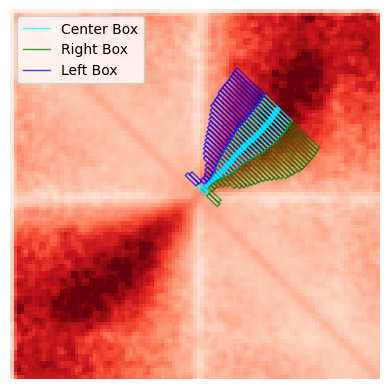

In [38]:
fig, ax = plt.subplots()

ax.imshow(A, cmap="Reds", interpolation="none", vmax=np.percentile(A, 98))

ax.scatter(coords[:, 0], coords[:, 1], color="deepskyblue", s=10, marker="o")

# Center
for i, c in enumerate(center_box_coords):
    coords_arr = np.array(c)
    if i == 0:
        ax.plot(coords_arr[:, 0], coords_arr[:, 1],
                color='cyan', linestyle='-', linewidth=1, alpha=0.75,
                marker=None, label='Center Box')
    else:
        ax.plot(coords_arr[:, 0], coords_arr[:, 1],
                color='cyan', linestyle='-', linewidth=1, alpha=0.75,
                marker=None)

# Right
for i, c in enumerate(right_box_coords):
    coords_arr = np.array(c)
    if i == 0:
        ax.plot(coords_arr[:, 0], coords_arr[:, 1],
                color='green', linestyle='-', linewidth=1, alpha=0.75,
                marker=None, label='Right Box')
    else:
        ax.plot(coords_arr[:, 0], coords_arr[:, 1],
                color='green', linestyle='-', linewidth=1, alpha=0.75,
                marker=None)

# Left
for i, c in enumerate(left_box_coords):
    coords_arr = np.array(c)
    if i == 0:
        ax.plot(coords_arr[:, 0], coords_arr[:, 1],
                color='blue', linestyle='-', linewidth=1, alpha=0.75,
                marker=None, label='Left Box')
    else:
        ax.plot(coords_arr[:, 0], coords_arr[:, 1],
                color='blue', linestyle='-', linewidth=1, alpha=0.75,
                marker=None)
    
ax.legend()
    

ax.set_axis_off()

plt.show()

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

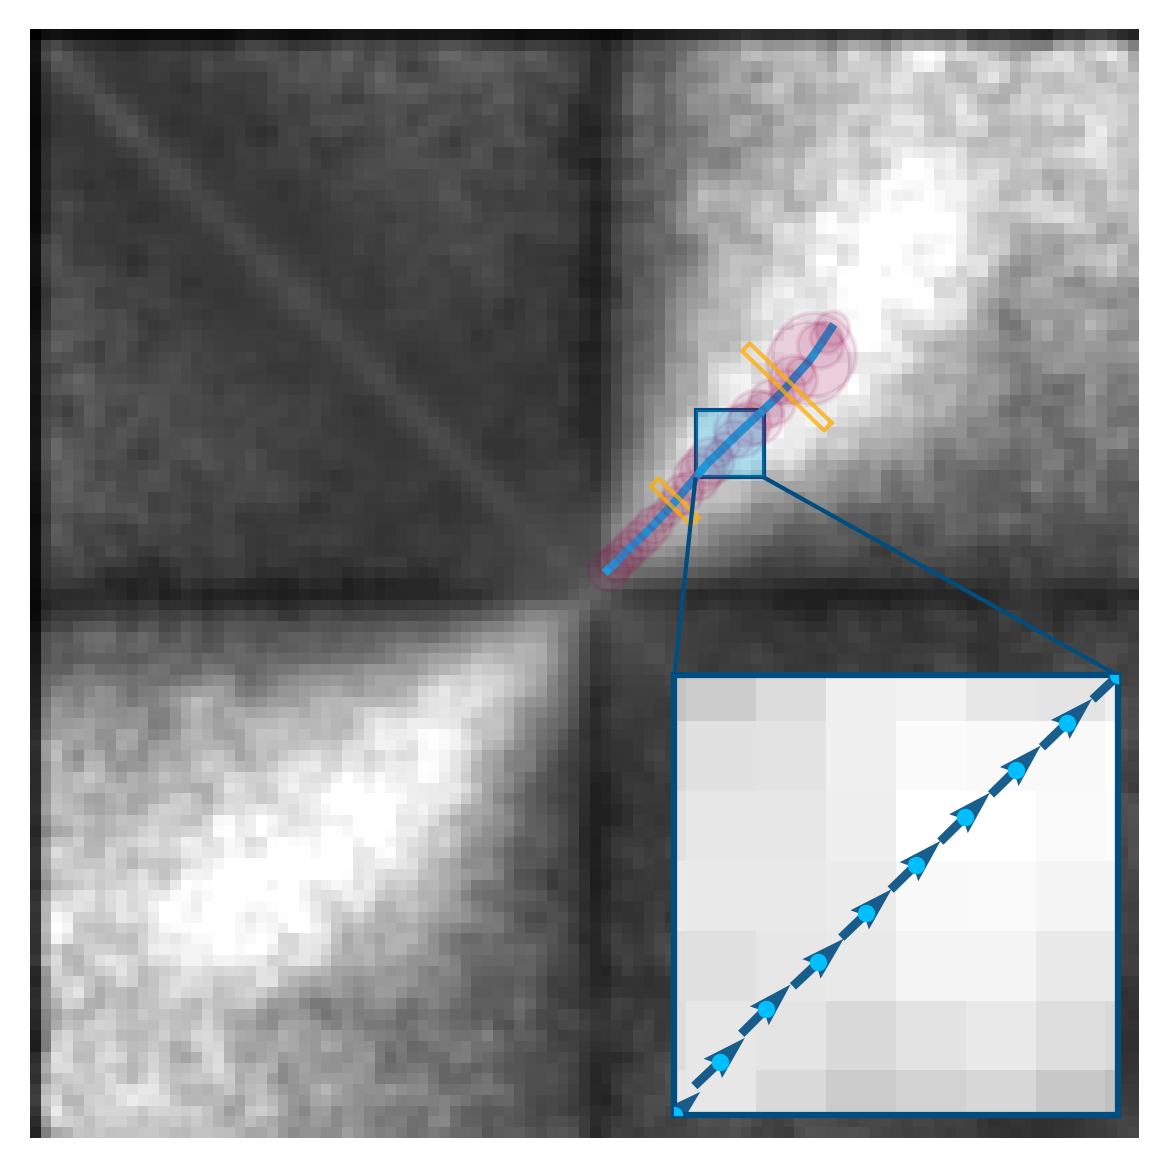

In [349]:
K = 6
fig, ax = plt.subplots(dpi=300)

ax.imshow(A, cmap="gray", interpolation="none", vmax=np.percentile(A, 98))

ax.plot(coords[:, 0], coords[:, 1], c="deepskyblue", linewidth=2, zorder=5)

# Center
for i, c in enumerate(center_box_coords):

    # Width
    if i in [7, 22]:
        coords_arr = np.array(c)
        ax.plot(coords_arr[:, 0], coords_arr[:, 1],
                color="#FFAE00", linestyle='-', linewidth=1, alpha=0.75, zorder=10,
                marker=None)
        

for i in range(len(z_saliency_vals)):

    # if i % K:
    #     continue

    j = len(z_saliency_vals) - 1 - i  # Reverse order for larger points first
    # ax.scatter(x_vals[i], y_vals[i], zorder=5, color="#970E53", s=(z_saliency_vals[j] * 12.5) ** 9 / 10e6, alpha=0.2)
    ax.scatter(x_vals[i], y_vals[i], zorder=5,color="#970E53", s=(z_saliency_vals[i] * 500), alpha=0.1)

# Inset
inset_face = "deepskyblue"
inset_border = "#004D80"

x1_zoom = x_vals[10:20][0]
x2_zoom = x_vals[10:20][-1]

y1_zoom = y_vals[10:20][0]
y2_zoom = y_vals[10:20][-1]

ax.add_patch(plt.Rectangle((x1_zoom, y1_zoom),
                           x2_zoom - x1_zoom, y2_zoom - y1_zoom, 
                           facecolor=inset_face, zorder=5, alpha=0.25))

axins = inset_axes(ax, width="40%", height="40%", loc='lower right')

axins.imshow(A, cmap='gray', interpolation="none", vmax=np.percentile(A, 98), origin='lower', alpha=0.85)
axins.set_xlim(x2_zoom, x1_zoom)
axins.set_ylim(y2_zoom, y1_zoom)
axins.set_xticks([])
axins.set_yticks([])


for spine in axins.spines.values():
    spine.set_visible(True) 
    spine.set_edgecolor(inset_border)
    spine.set_linewidth(1.5)

mark_inset(ax, axins, loc1=1, loc2=2, fc="none", ec=inset_border)

axins.scatter(coords[:, 0], coords[:, 1], color="deepskyblue", s=10, marker="o", zorder=10)

for i in range(len(theta_vals)):
    theta = theta_vals[i] - np.pi/2  
    axins.quiver(x_vals[i], y_vals[i], 
                 np.cos(theta), np.sin(theta), 
                 pivot='middle',
                 angles='xy', scale_units='xy',  
                 scale=1, 
                 color="#004D80",
                 width=0.02,
                 alpha=0.9,
                 zorder=5)


ax.set_axis_off()
# Turn axis off


plt.show()